In [1]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os


from zodiax.optimisation import sgd, adam

import amigo
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/miniforge3/envs/nuke/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/PDS70/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/PDS70/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/PDS70/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if file[0].header["TARGPROP"] == "TD-PDS-70":
        file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

In [4]:
from astropy.time import Time

for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")
    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}'
    )

HD 228337 F480M, Dither 1/1, Roll 302.2deg, 15.2min, 2023-02-24 19:20:07.785
TD-PDS-70 F480M, Dither 1/1, Roll 301.7deg, 50.5min, 2023-02-24 21:05:08.000


In [5]:
from scipy.ndimage import binary_dilation


def get_depth(exp, threshold=30_000):
    depth_cube = []
    for group in exp.ramp[1:]:
        group = np.where(exp.badpix, np.nan, group)
        sat_badpix = binary_dilation(group > threshold)
        depth_cube.append(sat_badpix)

    return (exp.ngroups - 1) - np.array(depth_cube, dtype=int).sum(0)


def fudge_cov_pp(cov, d, bajillion):
    cov = cov.at[d:, :].set(0.0)
    cov = cov.at[:, d:].set(0.0)
    cov = cov.at[d:, d:].set(bajillion * np.eye((cov.shape[0] - d)))
    return cov


def fudge_cov(cov, depth, bajillion=1e6):
    """Modifies a (48, 48, 80, 80) covariance array in-place,
    using per-pixel depths (80, 80)"""
    h, w = depth.shape
    final_cov = np.empty_like(cov)

    for i in range(h):
        for j in range(w):
            d = int(depth[i, j])
            this_cov = fudge_cov_pp(cov[..., i, j], d, bajillion)
            final_cov = final_cov.at[..., i, j].set(this_cov)

    return final_cov

In [6]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

cal_exposures = [
    amigo.model_fits.SplineVisFit(file, use_cov=True) for file in cal_files
]
sci_exposures = [
    amigo.model_fits.SplineVisFit(file, use_cov=True) for file in sci_files
]
exposures = cal_exposures + sci_exposures

exposures = [
    exp.set("cov", fudge_cov(exp.cov, get_depth(exp, threshold=22_000)))
    for exp in exposures
]


model = amigo.core_models.AmigoModel(
    exposures,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    vis_model=amigo.vis_models.LogVisModel(
        load_dict(cache + "vis_basis.npy"), n_basis=420
    ),
    state=load_dict(cache + "calibration.npy"),
)

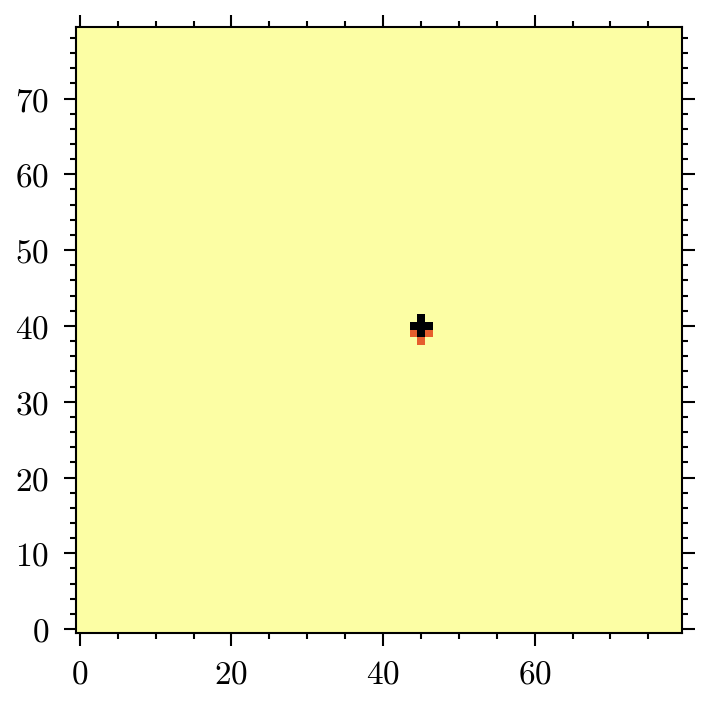

In [7]:
plt.imshow(get_depth(exposures[-1], threshold=22_000))

In [8]:
# for exp in exposures:
#     exp.print_summary()
#     amigo.plotting.summarise_fit(model, exp, residuals=False)

In [ ]:
n_epoch = 30

config = {
    # "positions": sgd(1e-1, 0),
    # "fluxes": sgd(5e-2, 0),
    # "aberrations": sgd(1e-1, 4),
    # "spectra": sgd(2e-1, 10),
    # "phases": sgd(2e0, 20),
    # "amplitudes": sgd(2e0, 20),
    #
    "positions": sgd(3e-3, 0),
    "fluxes": sgd(5e-3, 0),
    "aberrations": sgd(5e-3, 4),
    "spectra": sgd(1e-2, 10),
    "phases": sgd(1e-3, 20),
    "amplitudes": sgd(1e-3, 20),
}

trainer = amigo.fitting.Trainer(
    cache=os.path.join(amigo_cache, "fishers/"),
)

trainer = trainer.populate_fishers(
    model,
    exposures,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=list(config.keys()),
)

print("Number of exposures: ", len(exposures))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exposures,
    # batches=amigo.fitting.batch_exposures(exposures, n_batch=len(exposures) // 3),
)

Number of exposures:  2


  0%|          | 0/30 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 6,669.98
Estimated run time: 0:01:55
Full Time: 0:03:30
Final Loss: 386.62


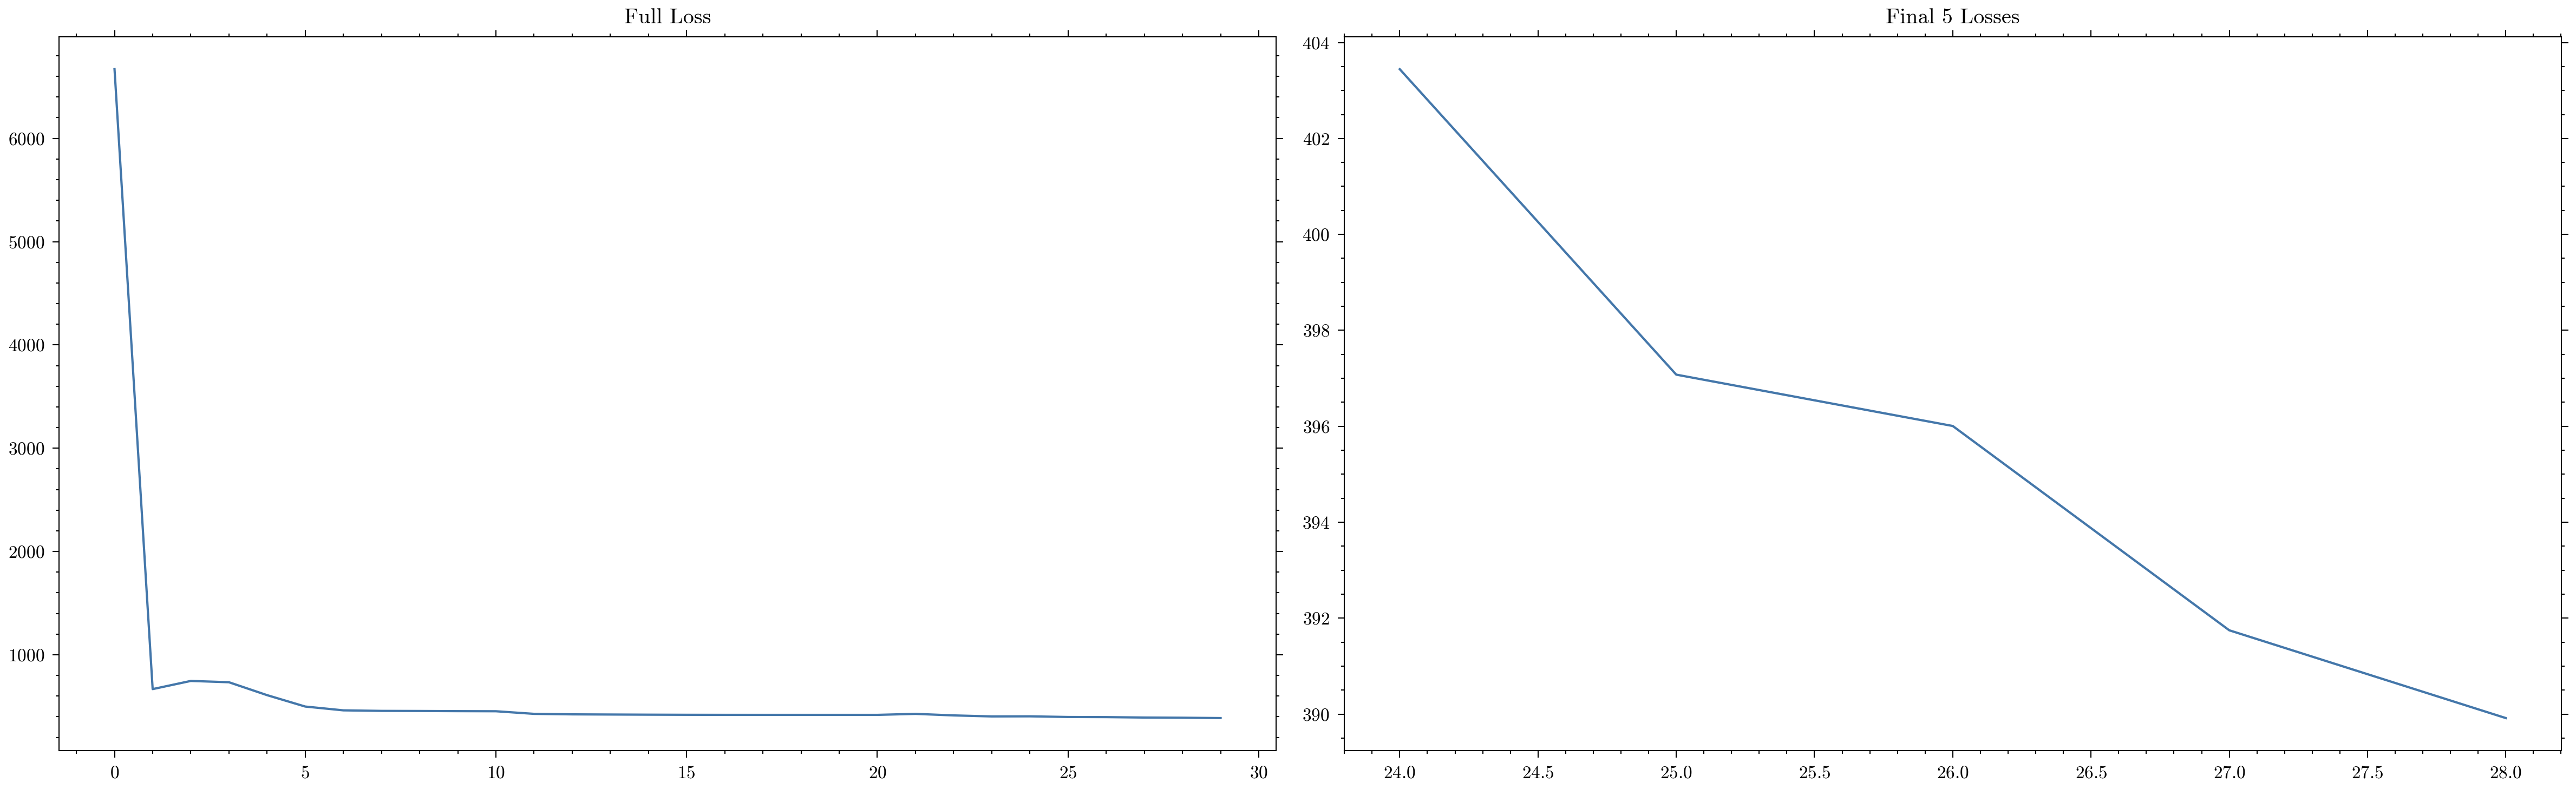

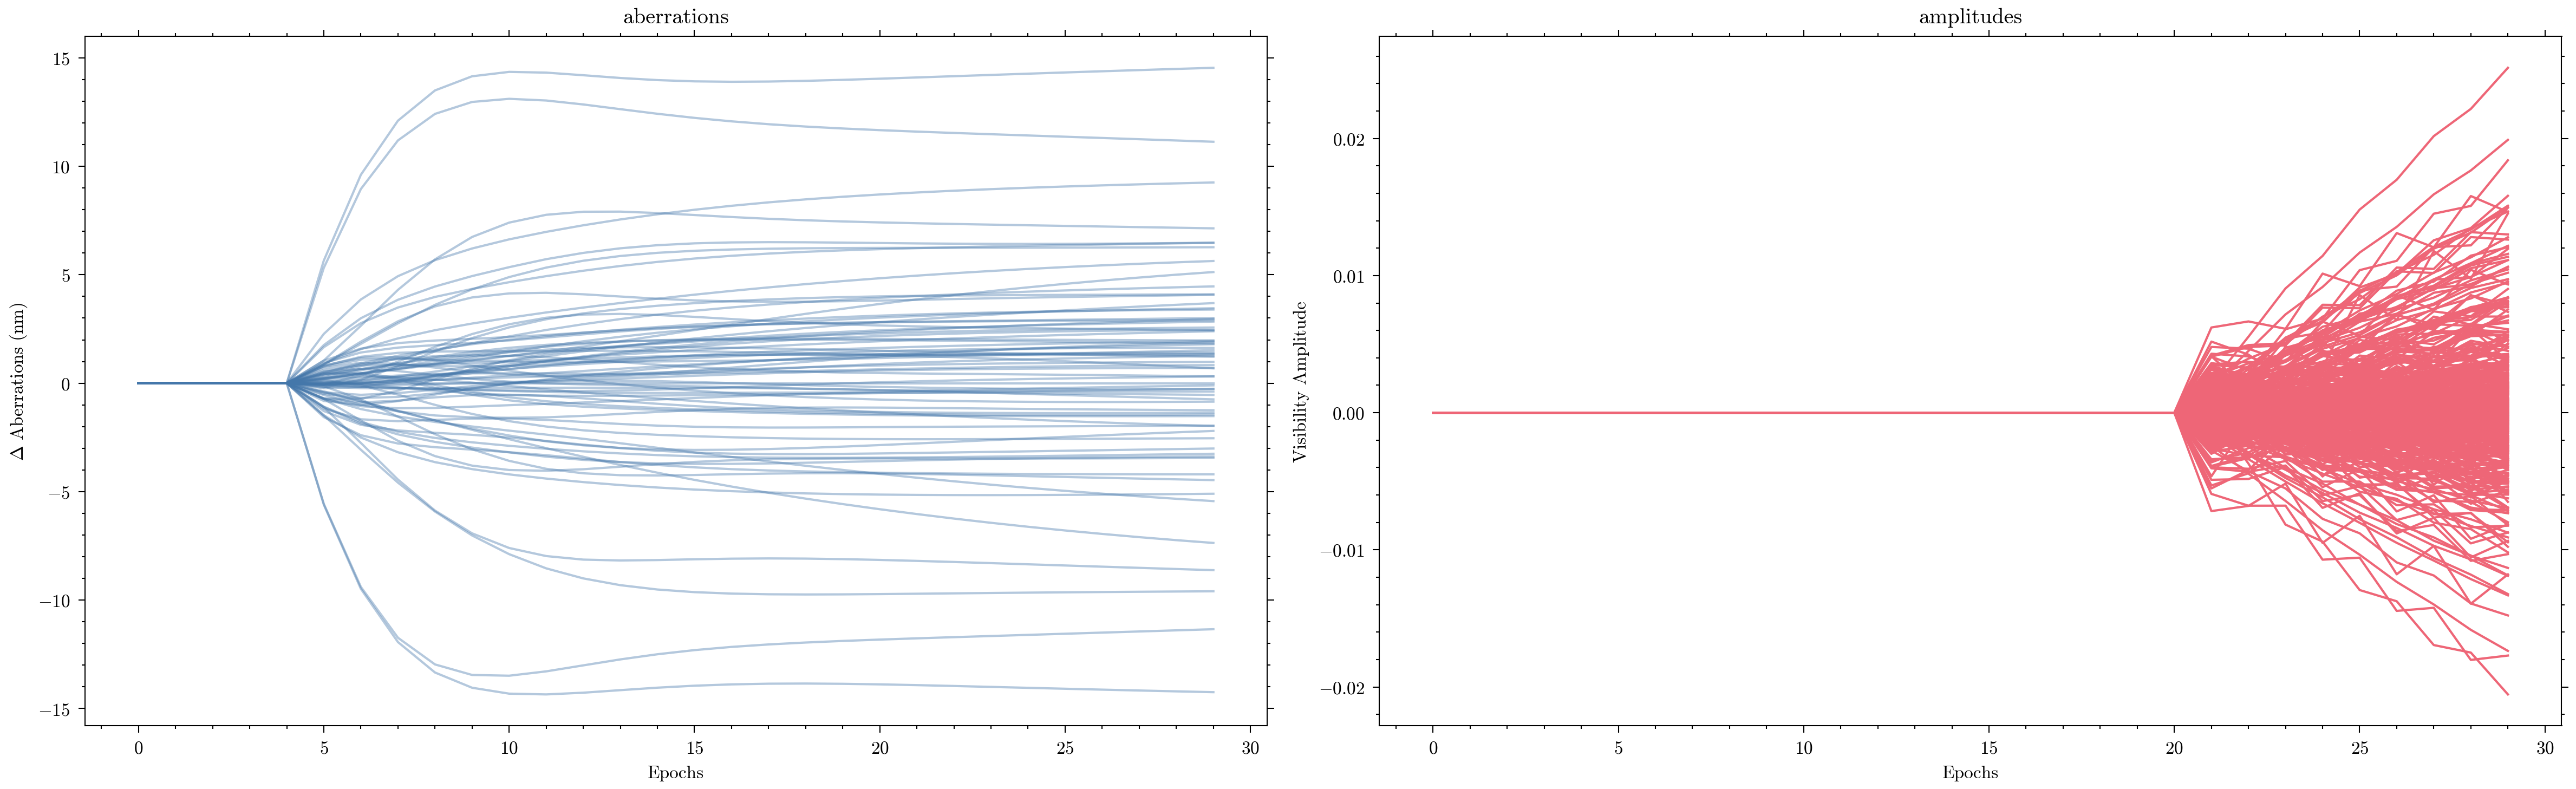

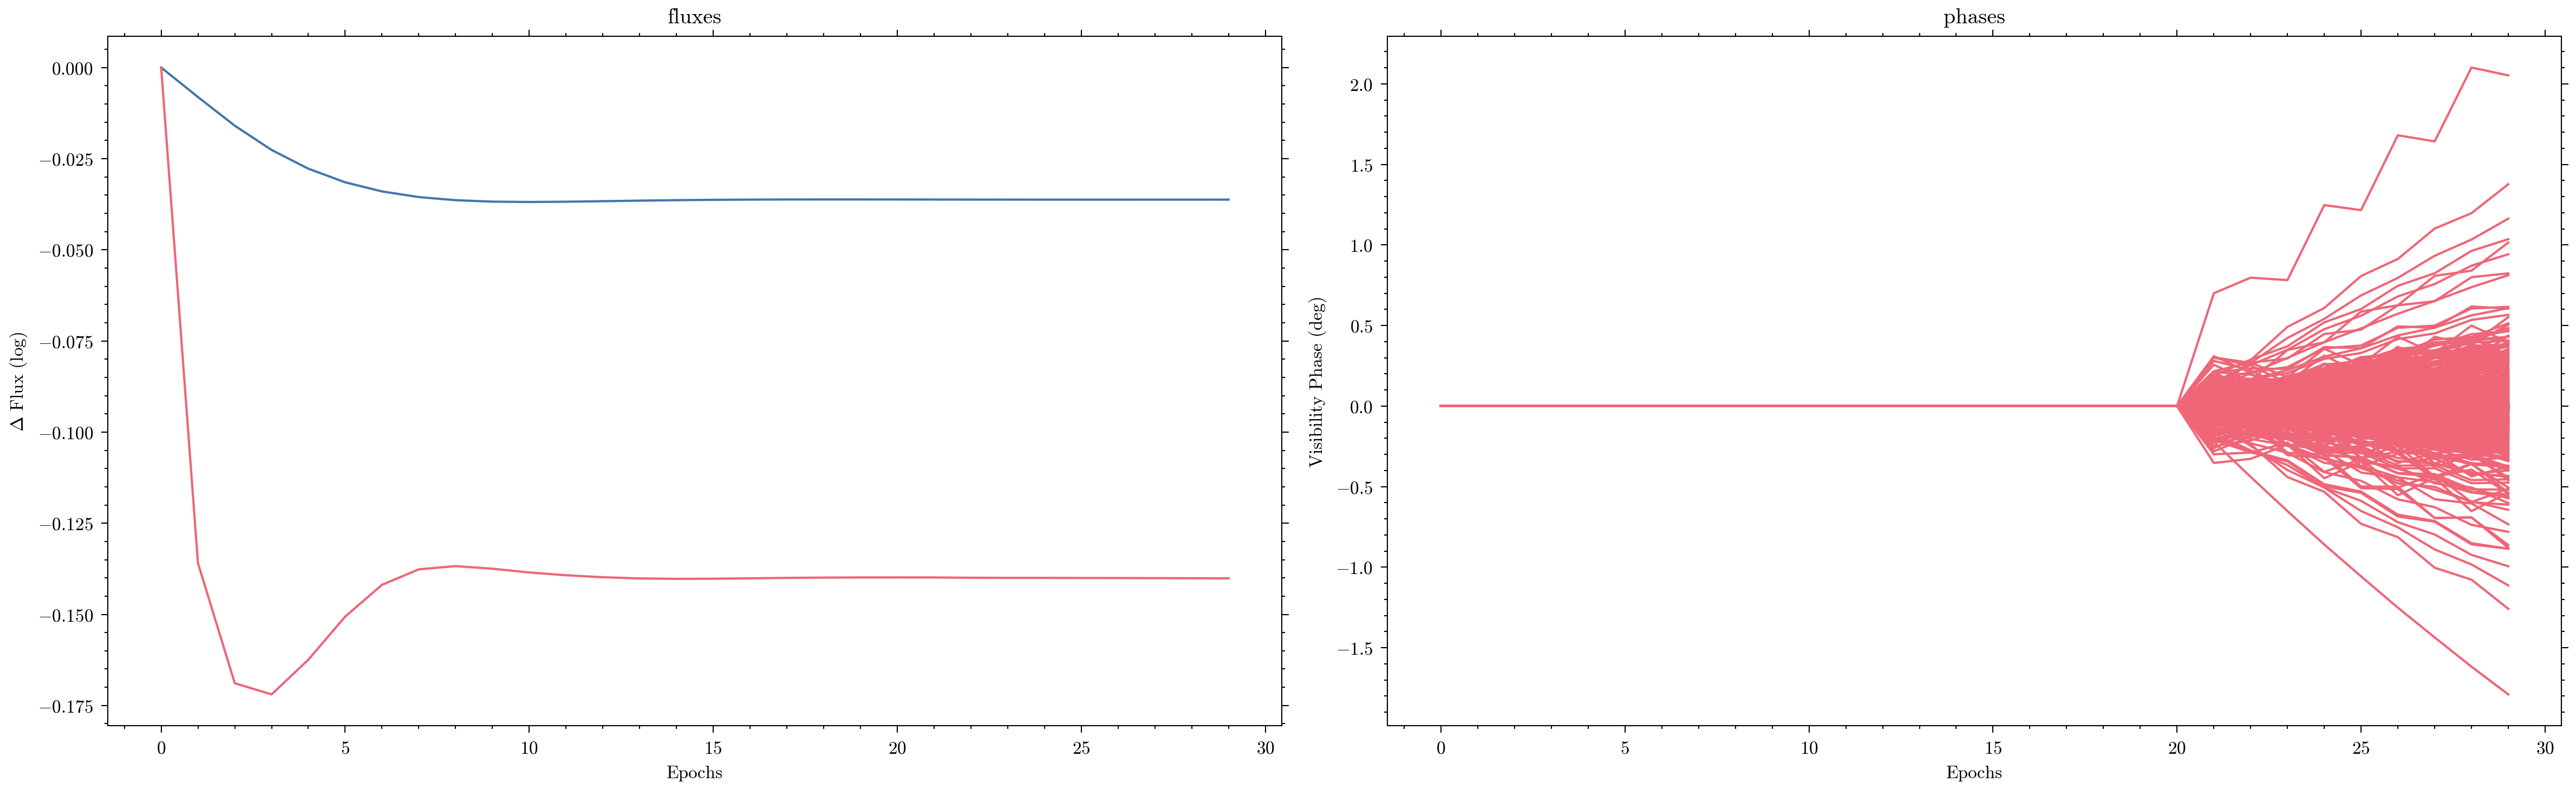

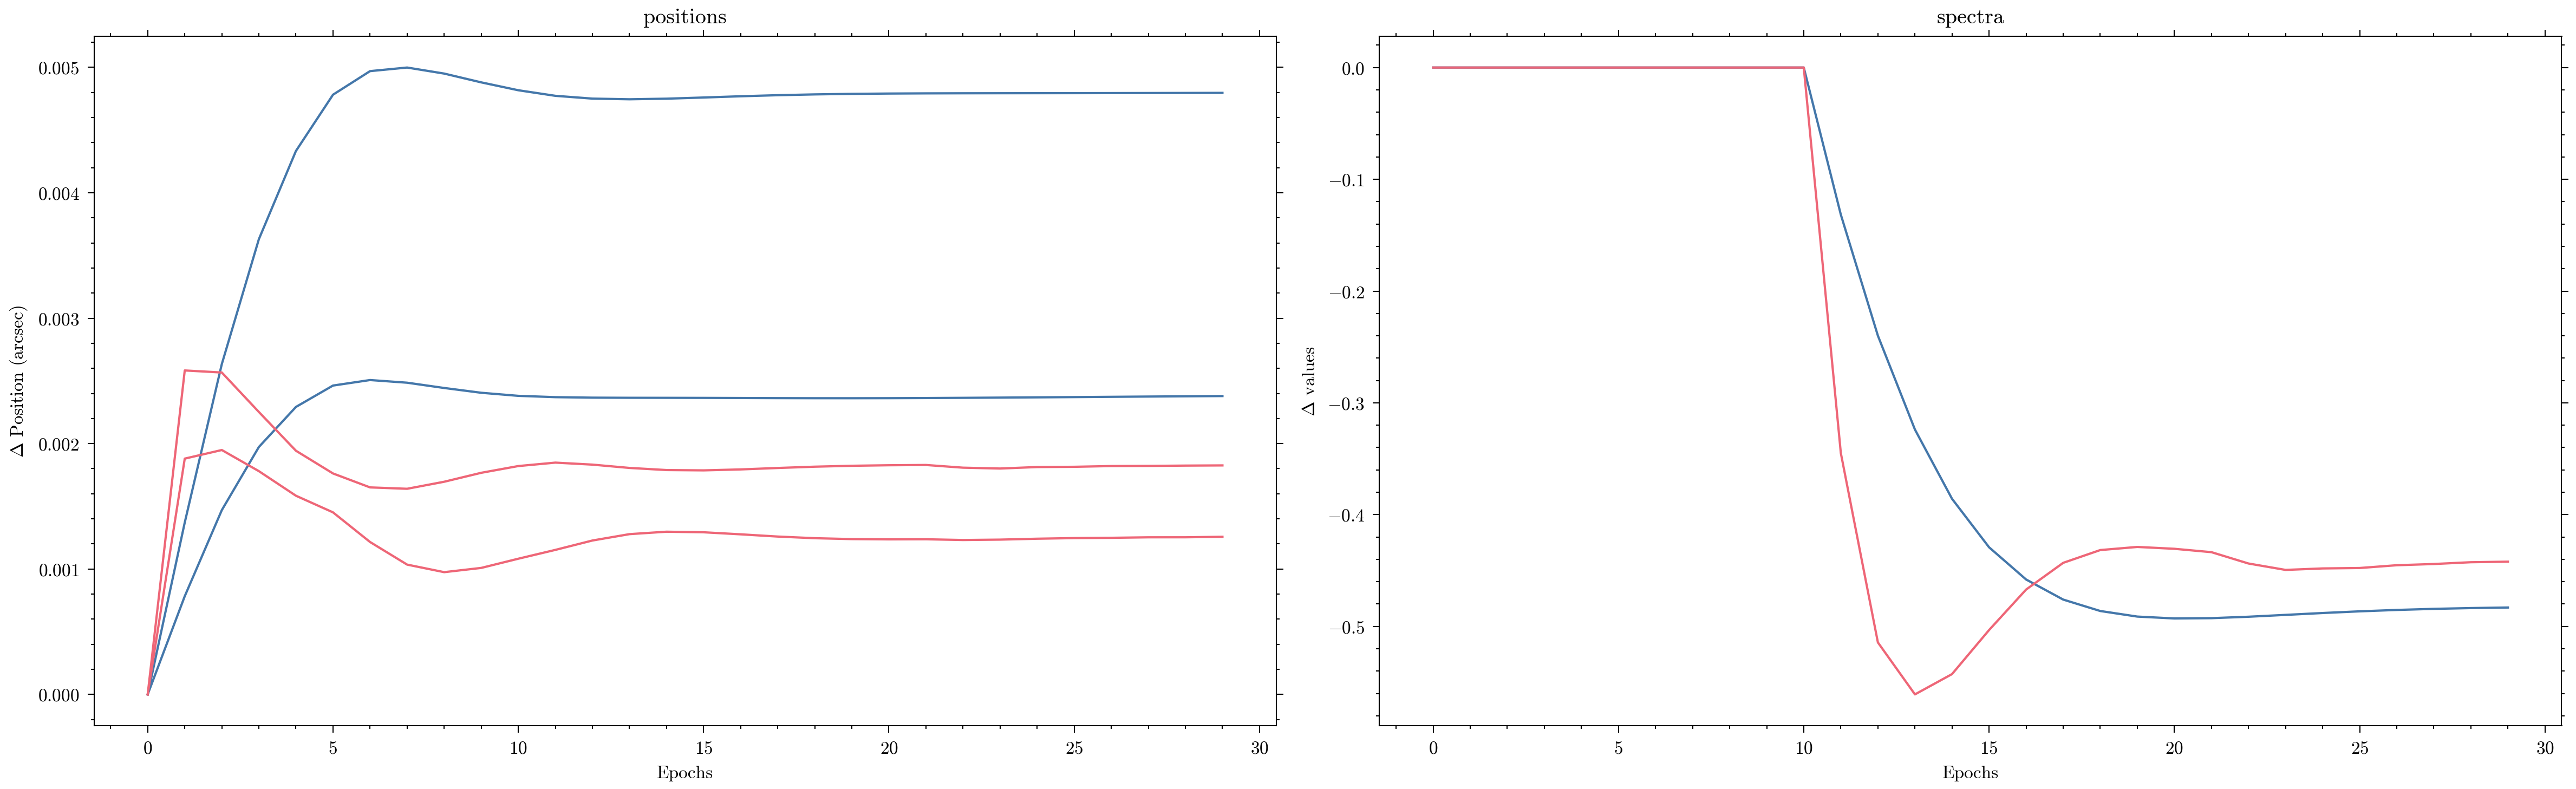

HD 228337


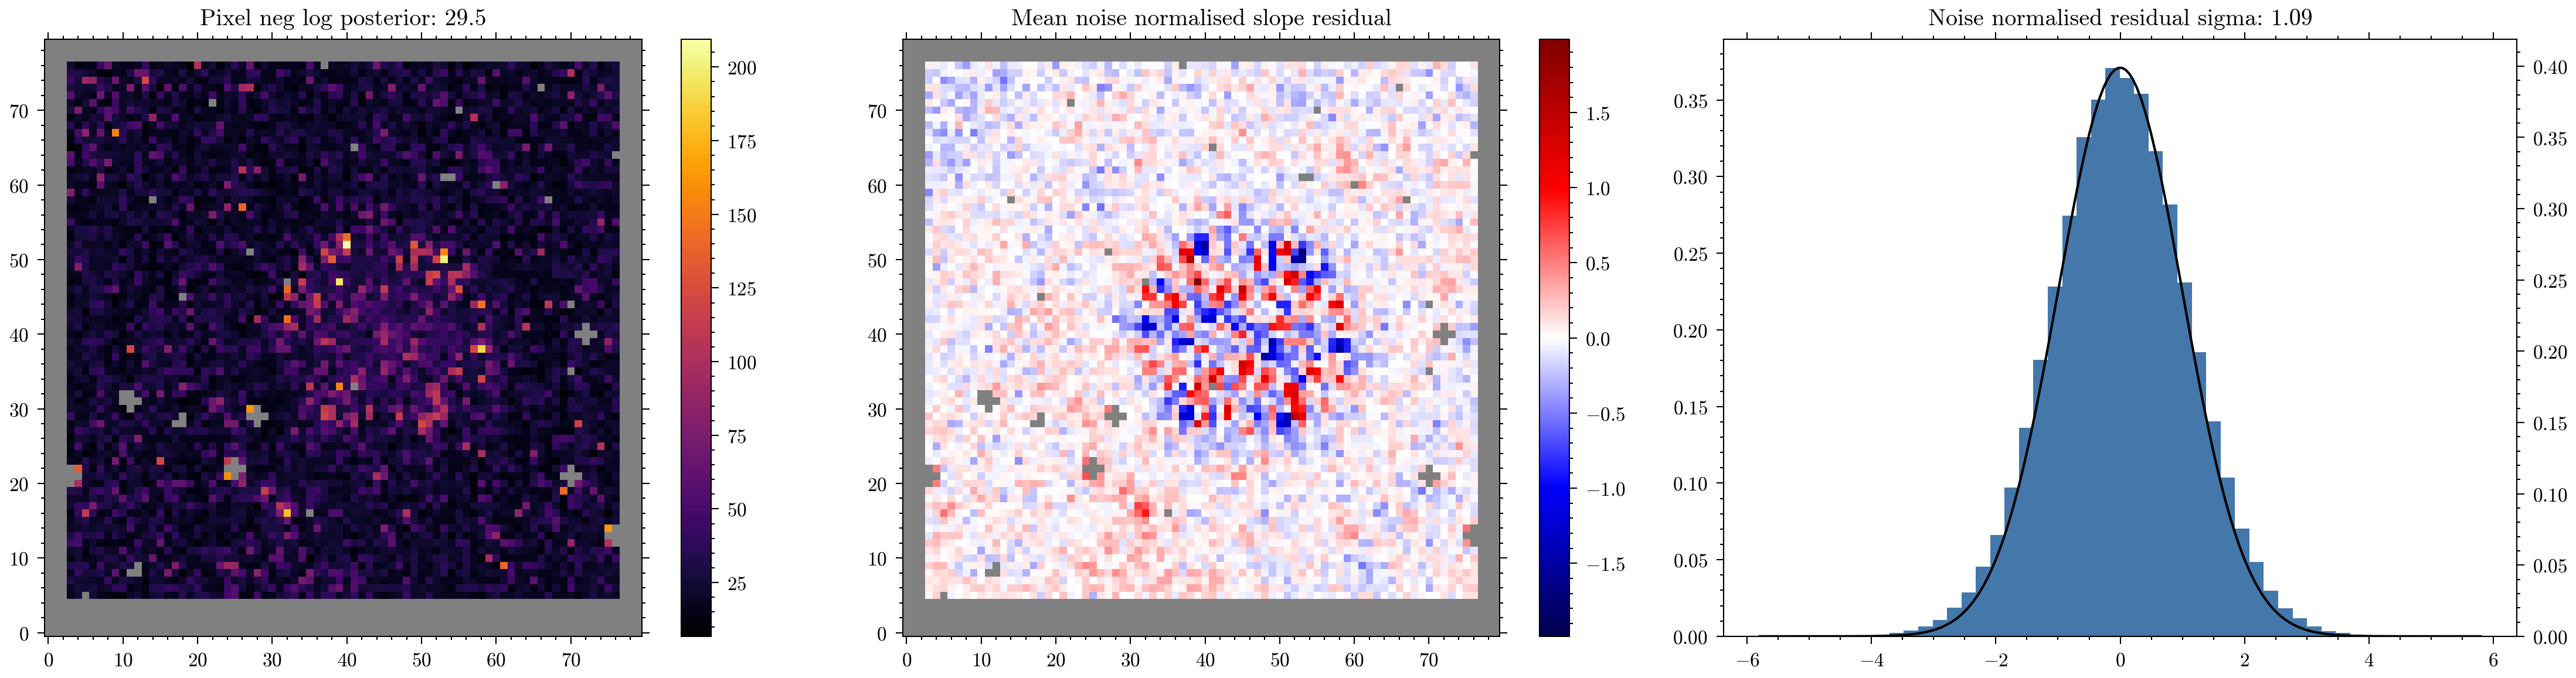

TD-PDS-70


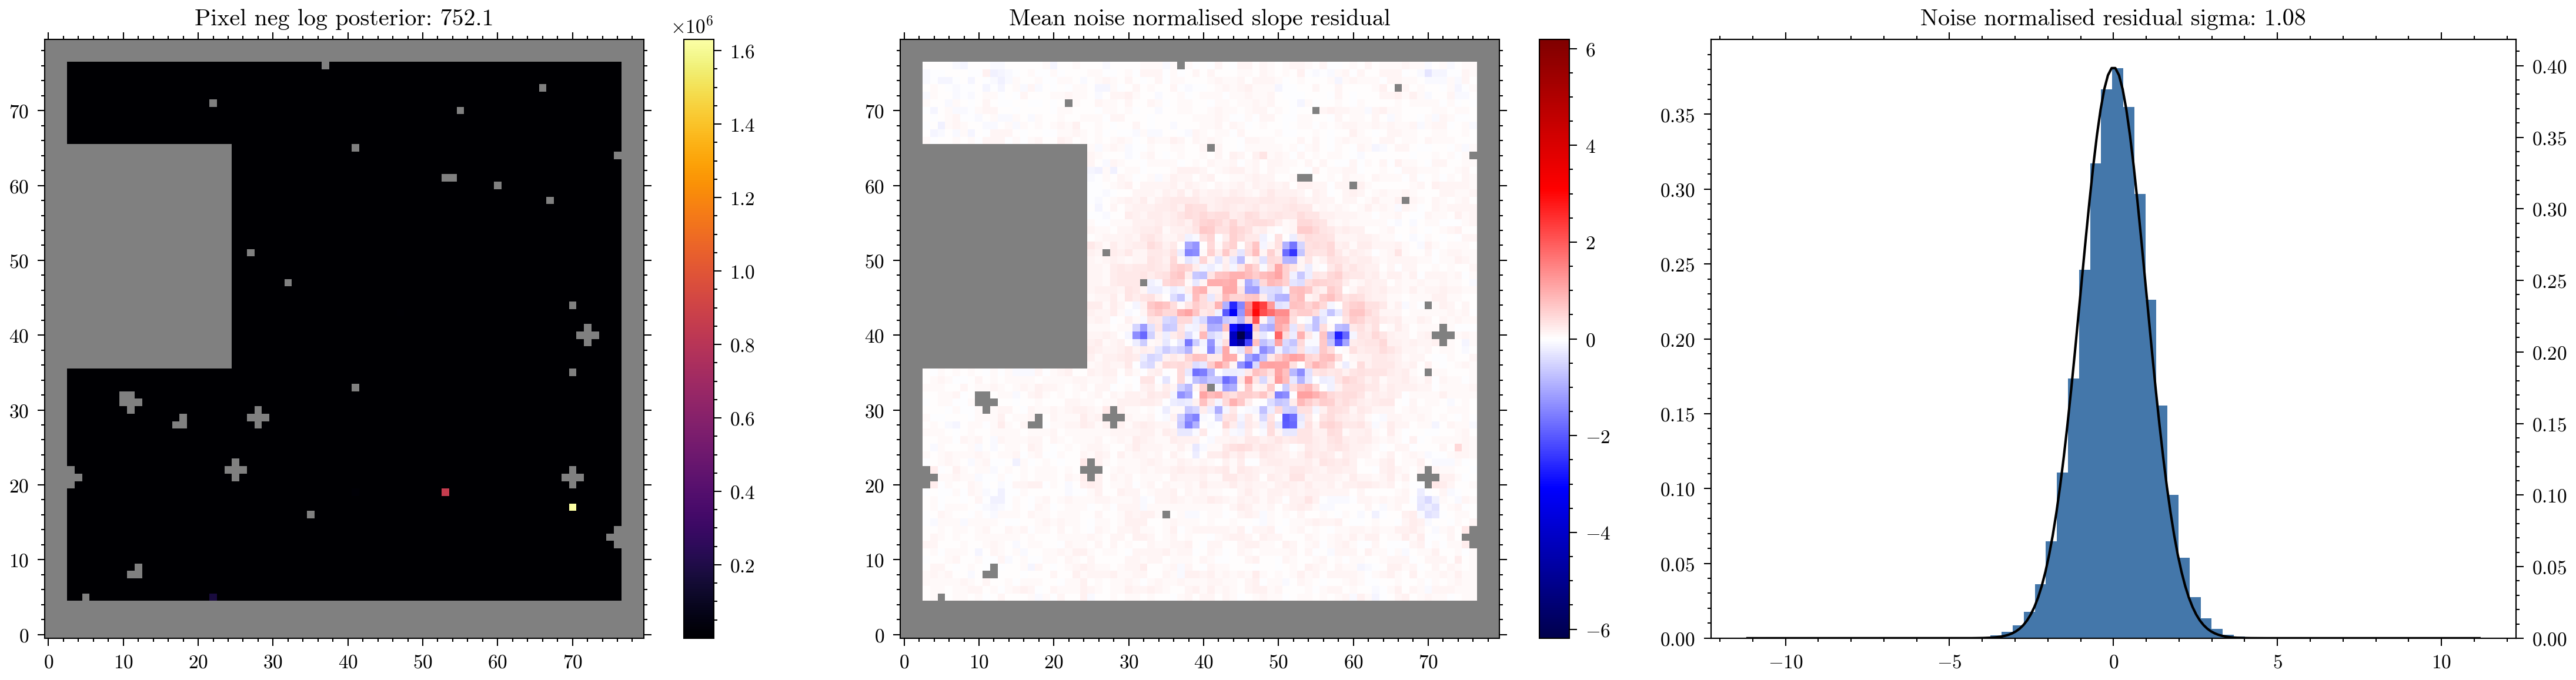

In [10]:
losses = np.array([v for v in result.losses.values()]).mean(0)

amigo.plotting.plot_losses(losses, start=int(0.8 * n_epoch))
amigo.plotting.plot(result.history)

# for exp in exposures:
for exp in exposures:
    print(exp.star)
    amigo.plotting.summarise_fit(result.model, exp)

In [ ]:
# zdx.experimental.serialise(output_path + "firstbigrun.zdx", result.model.params)

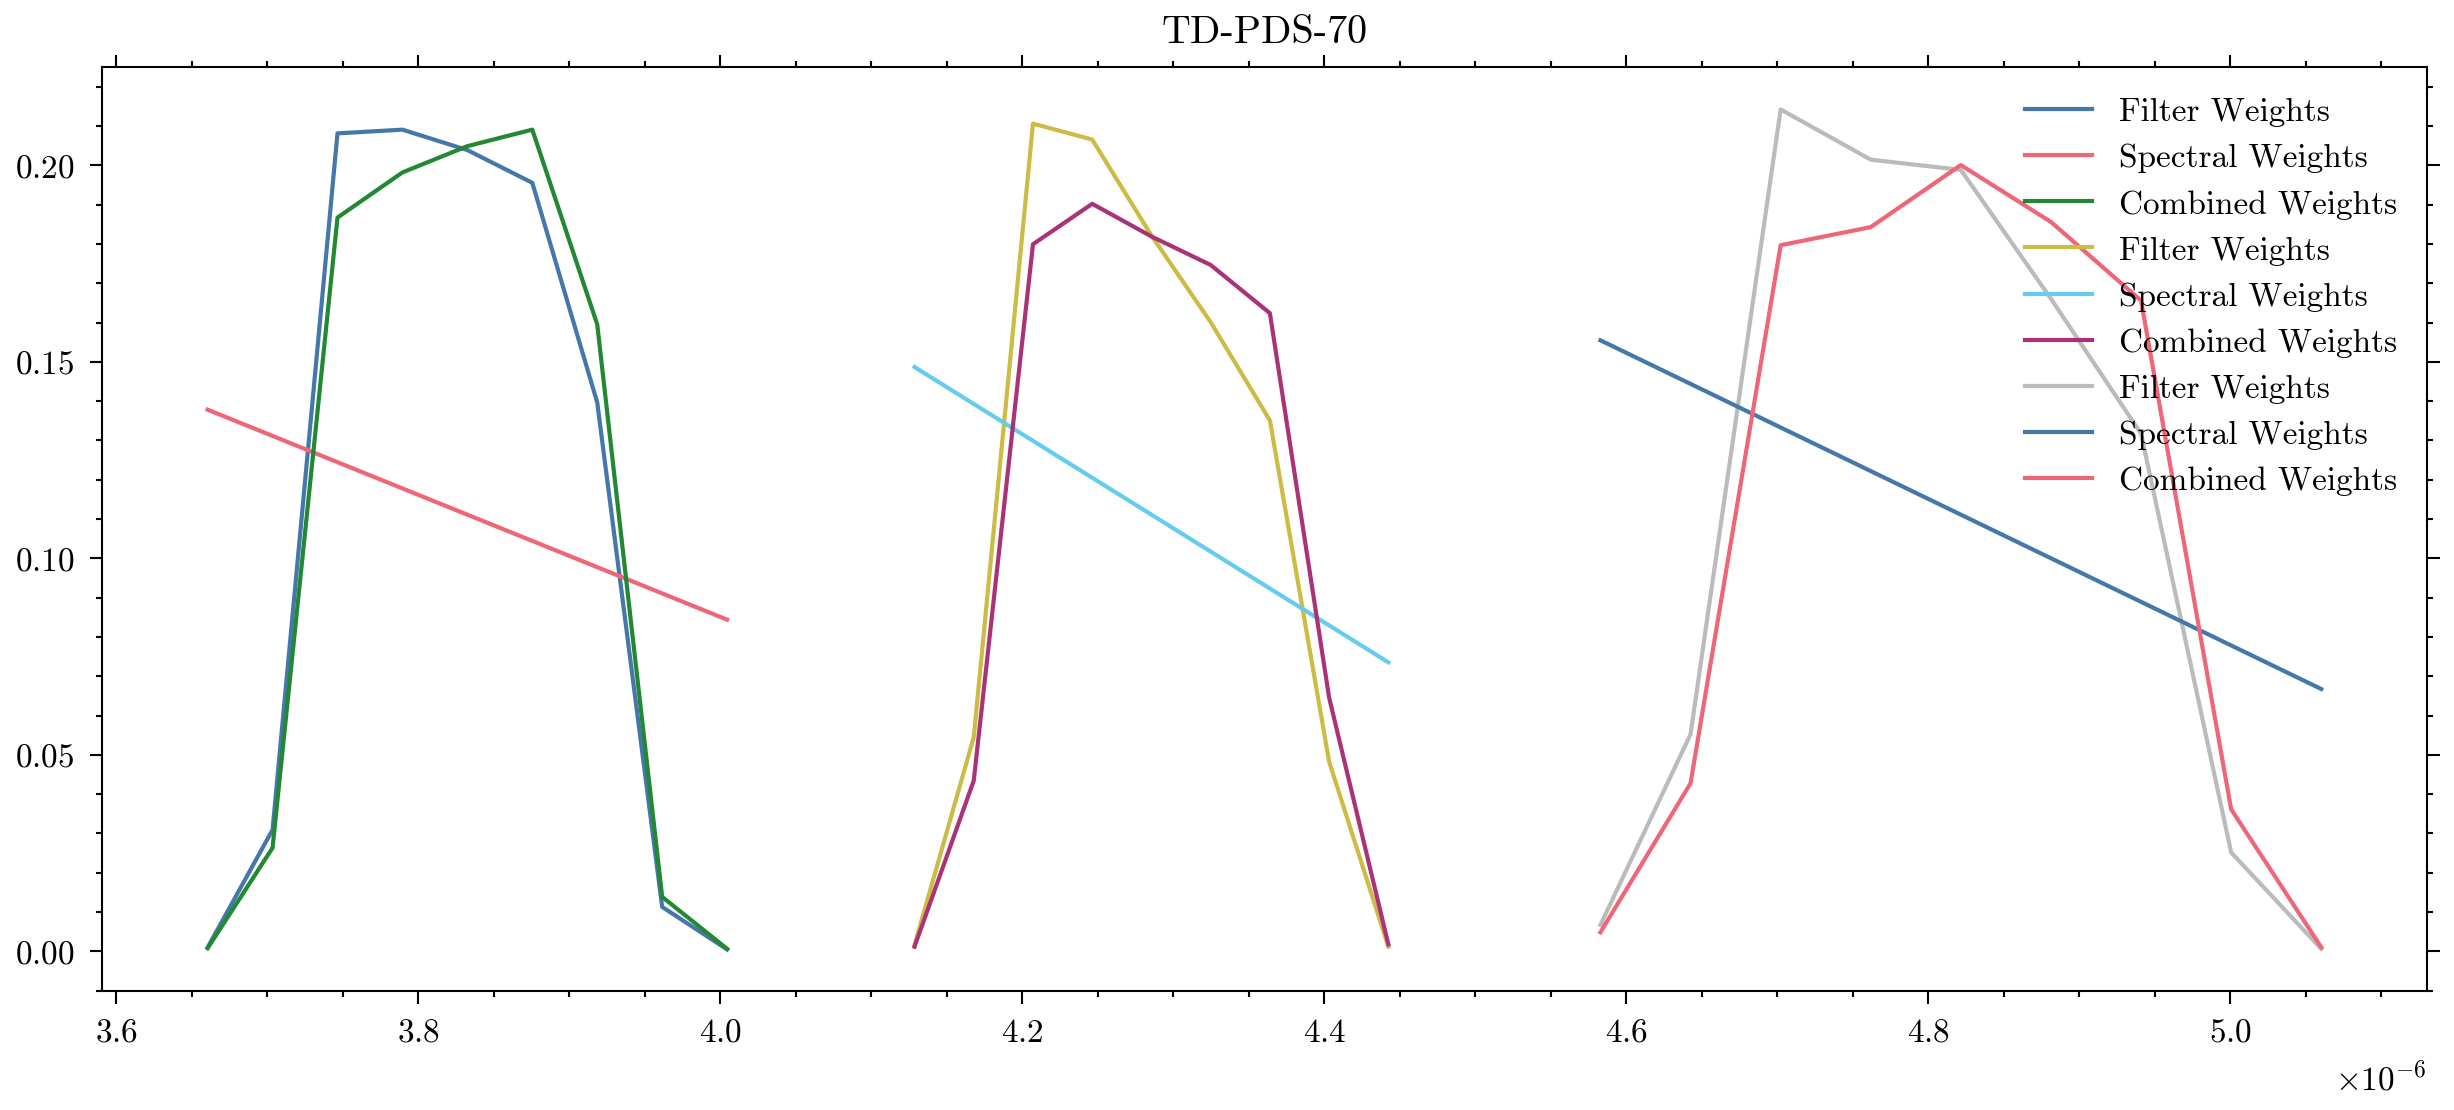

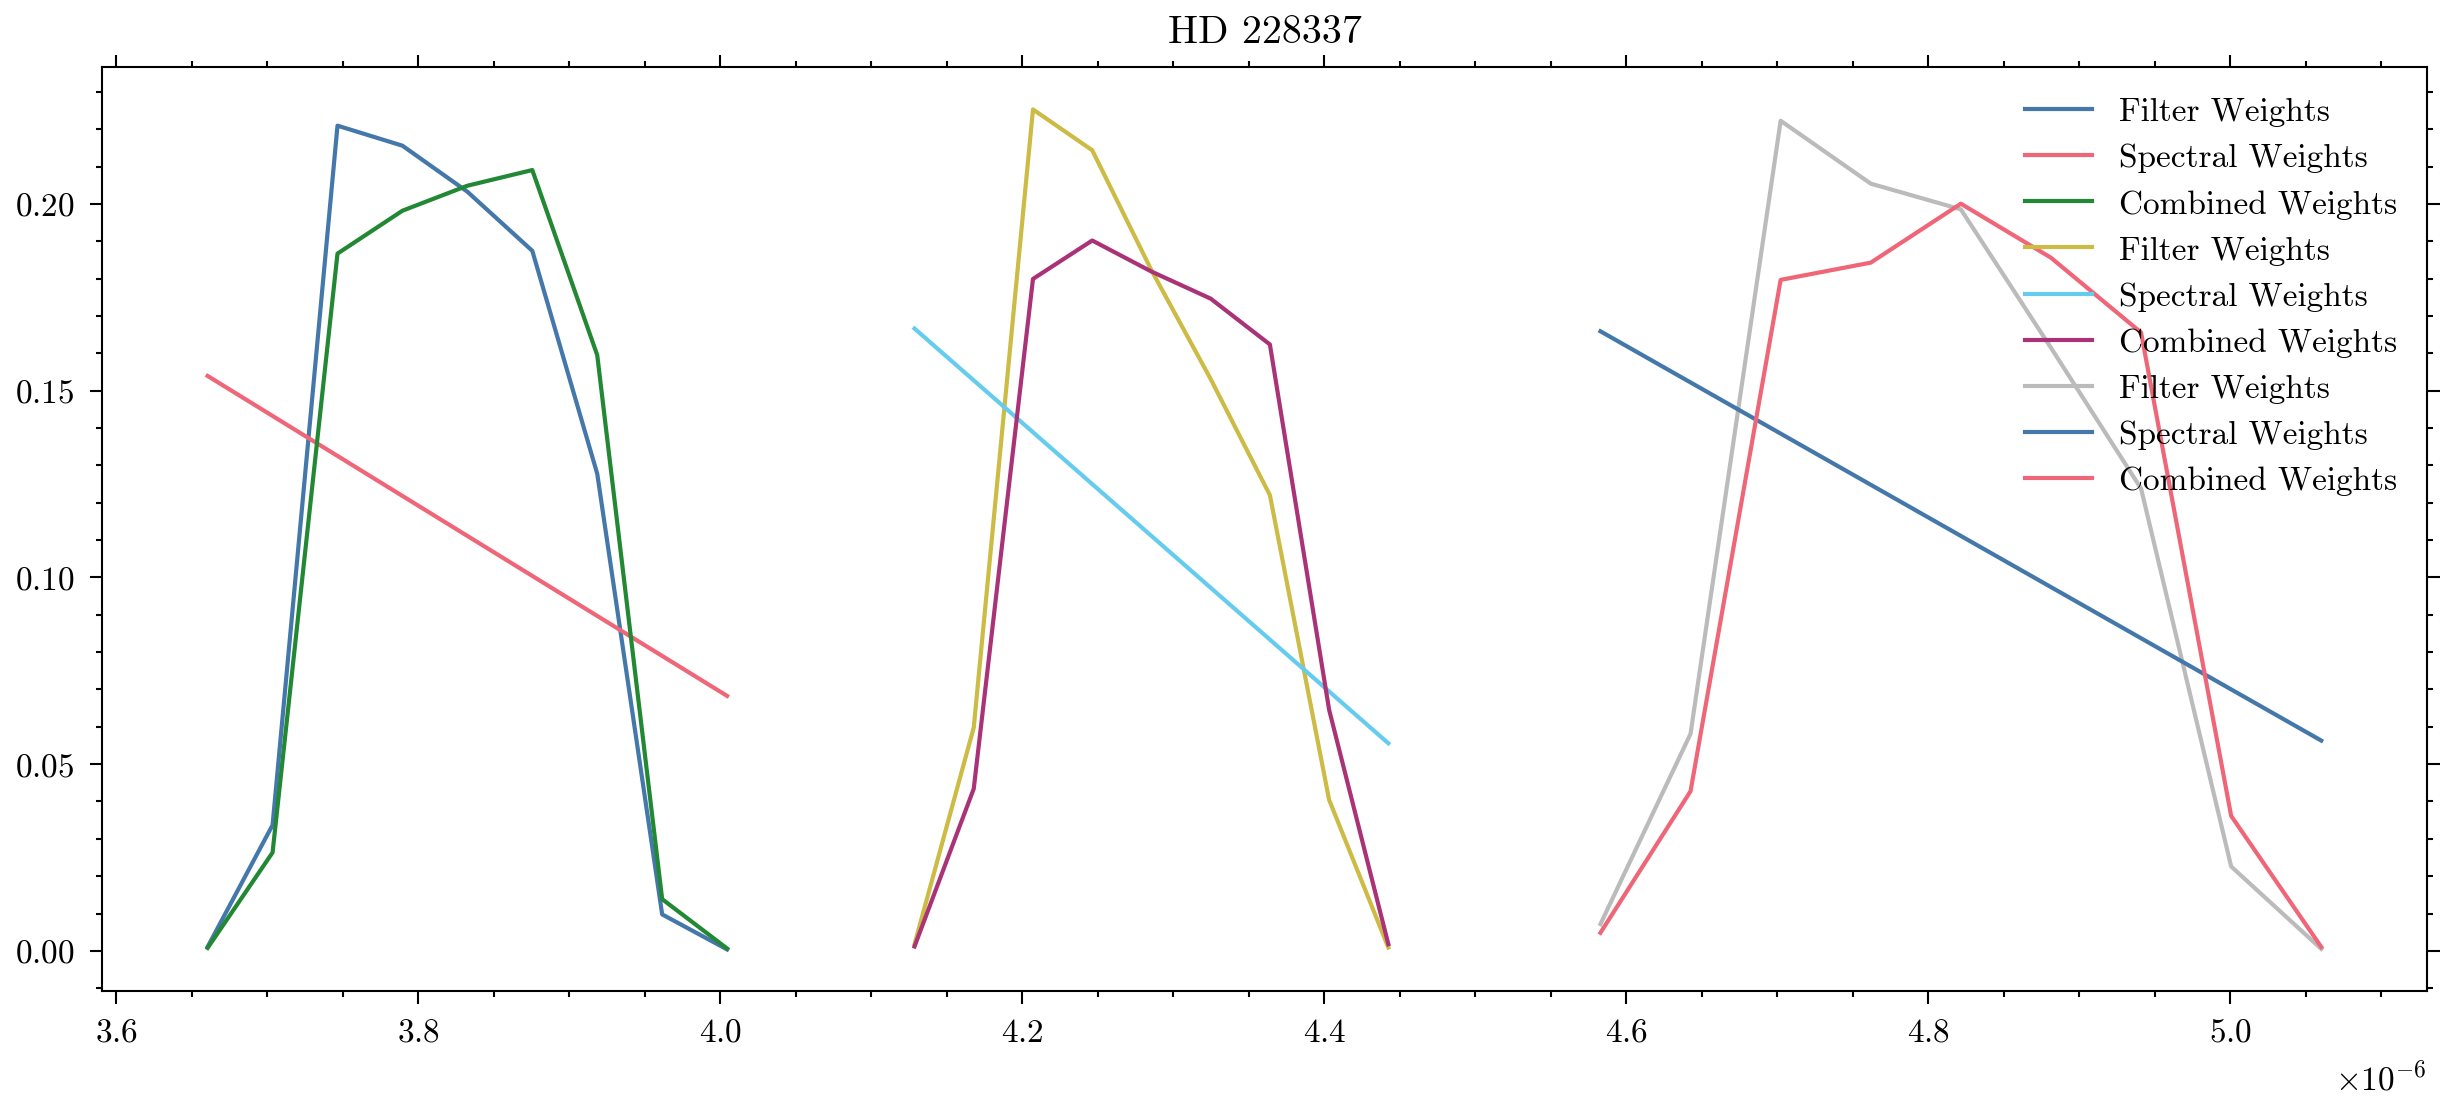

In [ ]:
stars = list(set([exp.star for exp in exposures]))

for targ_star in stars:
    plt.figure(figsize=(10, 4))
    plt.title(f"{targ_star}")
    for key, spec in result.model.spectra.items():
        star, filt = key.split("_")

        if star != targ_star:
            continue

        wavels, filt_weights = model.filters[filt]
        xs = np.linspace(-1, 1, len(wavels), endpoint=True)
        spectra_slopes = 1 + spec * xs
        weights = filt_weights * spectra_slopes  # * wavels

        #
        filt_weights = filt_weights / filt_weights.sum()
        spectra_slopes = spectra_slopes / spectra_slopes.sum()
        weights = weights / weights.sum()

        plt.plot(wavels, weights, label="Filter Weights")
        plt.plot(wavels, spectra_slopes, label="Spectral Weights")
        plt.plot(wavels, filt_weights, label="Combined Weights")

    plt.legend()
    plt.show()

In [ ]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args

    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    # Return the loss
    return -np.nanmean(exp.mv_zscore(model))


params = ["amplitudes", "phases", "fluxes", "spectra"]
final_model = result.model

args_out = {}
sols_out = {}
for exp in exposures:
    opt_params = {}
    fishers = {}
    shapes = {}
    for param in params:
        key = exp.map_param(param)
        shapes[key] = final_model.get(key).shape
        opt_params[key] = final_model.get(key).flatten()
        fishers[key] = trainer.fishers[f"{exp.key}.{param}"]

    shapes = ModelParams(shapes)
    model_params = ModelParams(opt_params)
    initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
    proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
    proj_mats = jtu.map(lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats)

    args = (final_model, exp, model_params, proj_mats, shapes)
    args_out[exp.key] = args

    try:
        print("Initial loss:", fun(initial_params, args))
    except Exception as e:
        print(f"Skipped {exp.key}")
        continue
    solver = optx.BFGS(rtol=1e-6, atol=1e-6)
    sol = optx.minimise(fun, solver, initial_params, args, throw=False, max_steps=2048)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

Initial loss: 15.987740486873289
Final loss: 15.987684762036888
321 144


Initial loss: 11.584612687417401
Final loss: 11.5842409377779
364 171


Initial loss: 6.188666551097653
Final loss: 6.18742225341359
512 213


Initial loss: 50.32228815539242
Final loss: 50.28844538355157
561 512


Initial loss: 34.74798913056267
Final loss: 34.72134612365781
330 250


Initial loss: 27.170112069782498
Final loss: 27.073370975894722
323 267




In [ ]:
spectra = {}
for key, args in args_out.items():
    proj_mats = args[3]
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

    # Spectra is joint-fit so we take the mean
    exp = args[1]
    spec = model_params.params[exp.map_param("spectra")]
    spec_key = exp.get_key("spectra")
    if spec_key not in spectra:
        spectra[spec_key] = [spec]
    else:
        spectra[spec_key].append(spec)

spectra = jtu.map(
    lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list)
)
final_model = final_model.set("spectra", spectra)

final_state = {}
for key, values in result.state.items():
    final_state[key] = final_model.get(key)

In [ ]:
# final_state = load_dict(output_path + "final_state.npy")

# params = {}
# for key, value in model.params.items():
#     if key in final_state.keys():
#         params[key] = final_state[key]
#     else:
#         params[key] = value
# final_model = model.set("params", params)

F380M Calibrator HD 228337 10


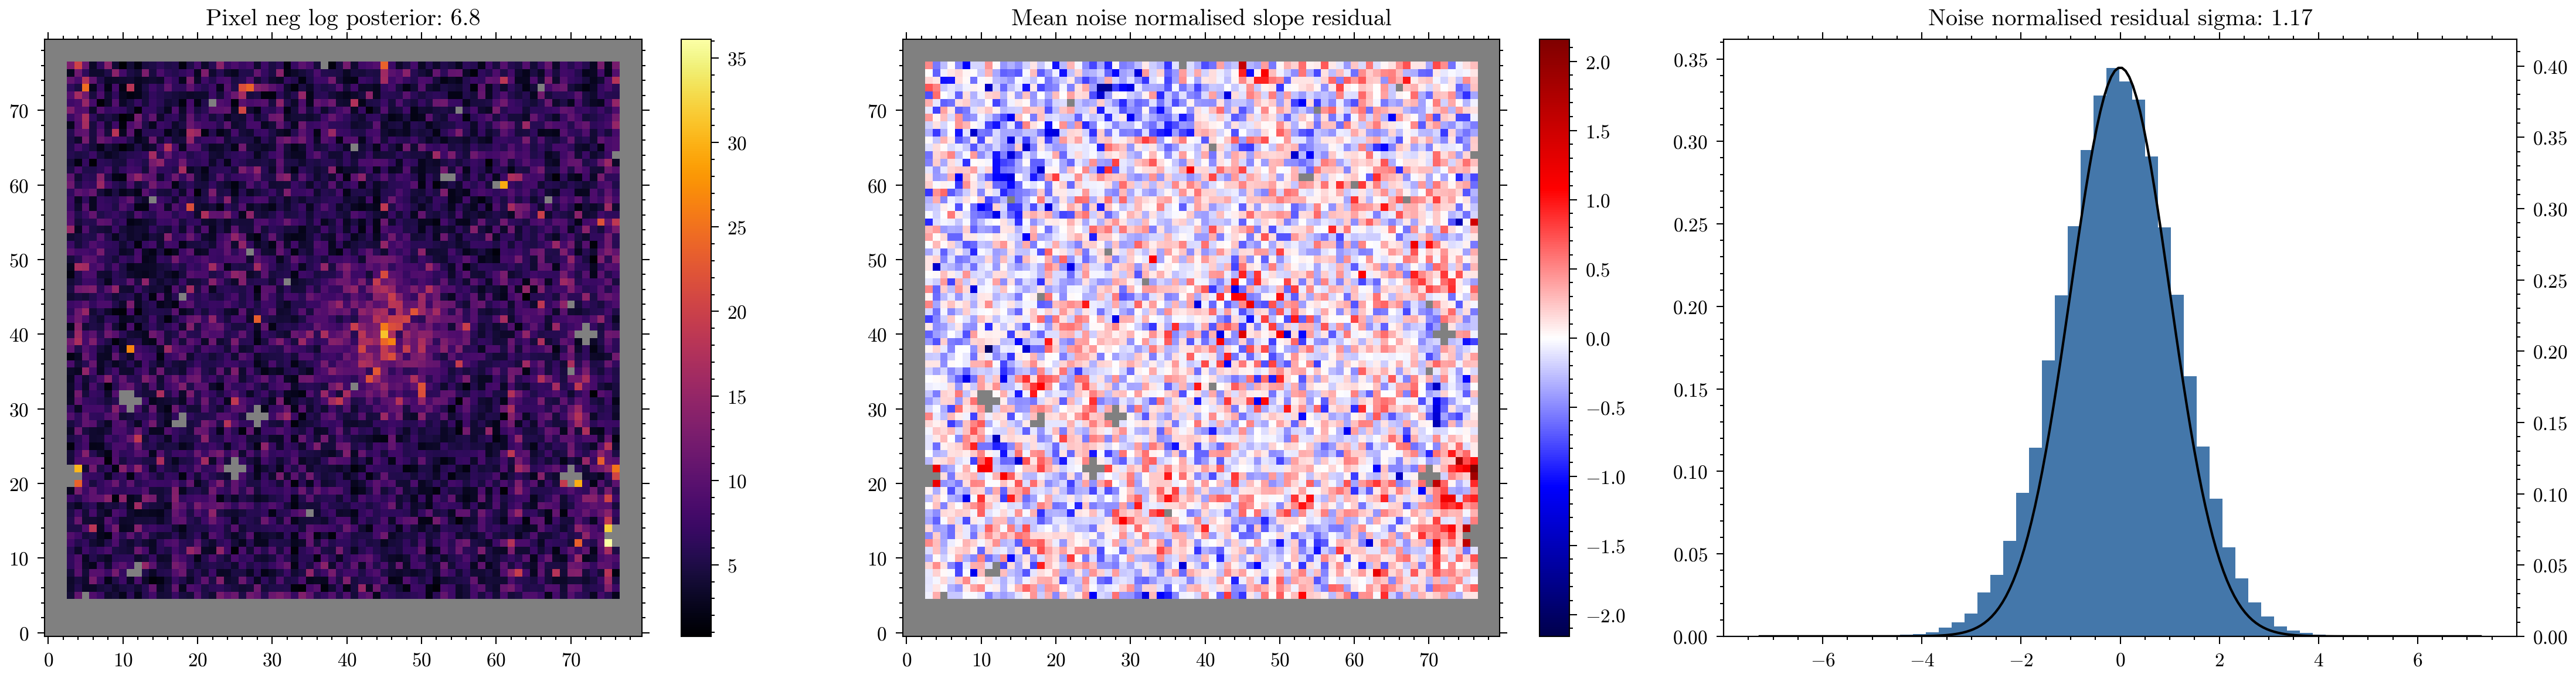

F380M Science TD-PDS-70 49


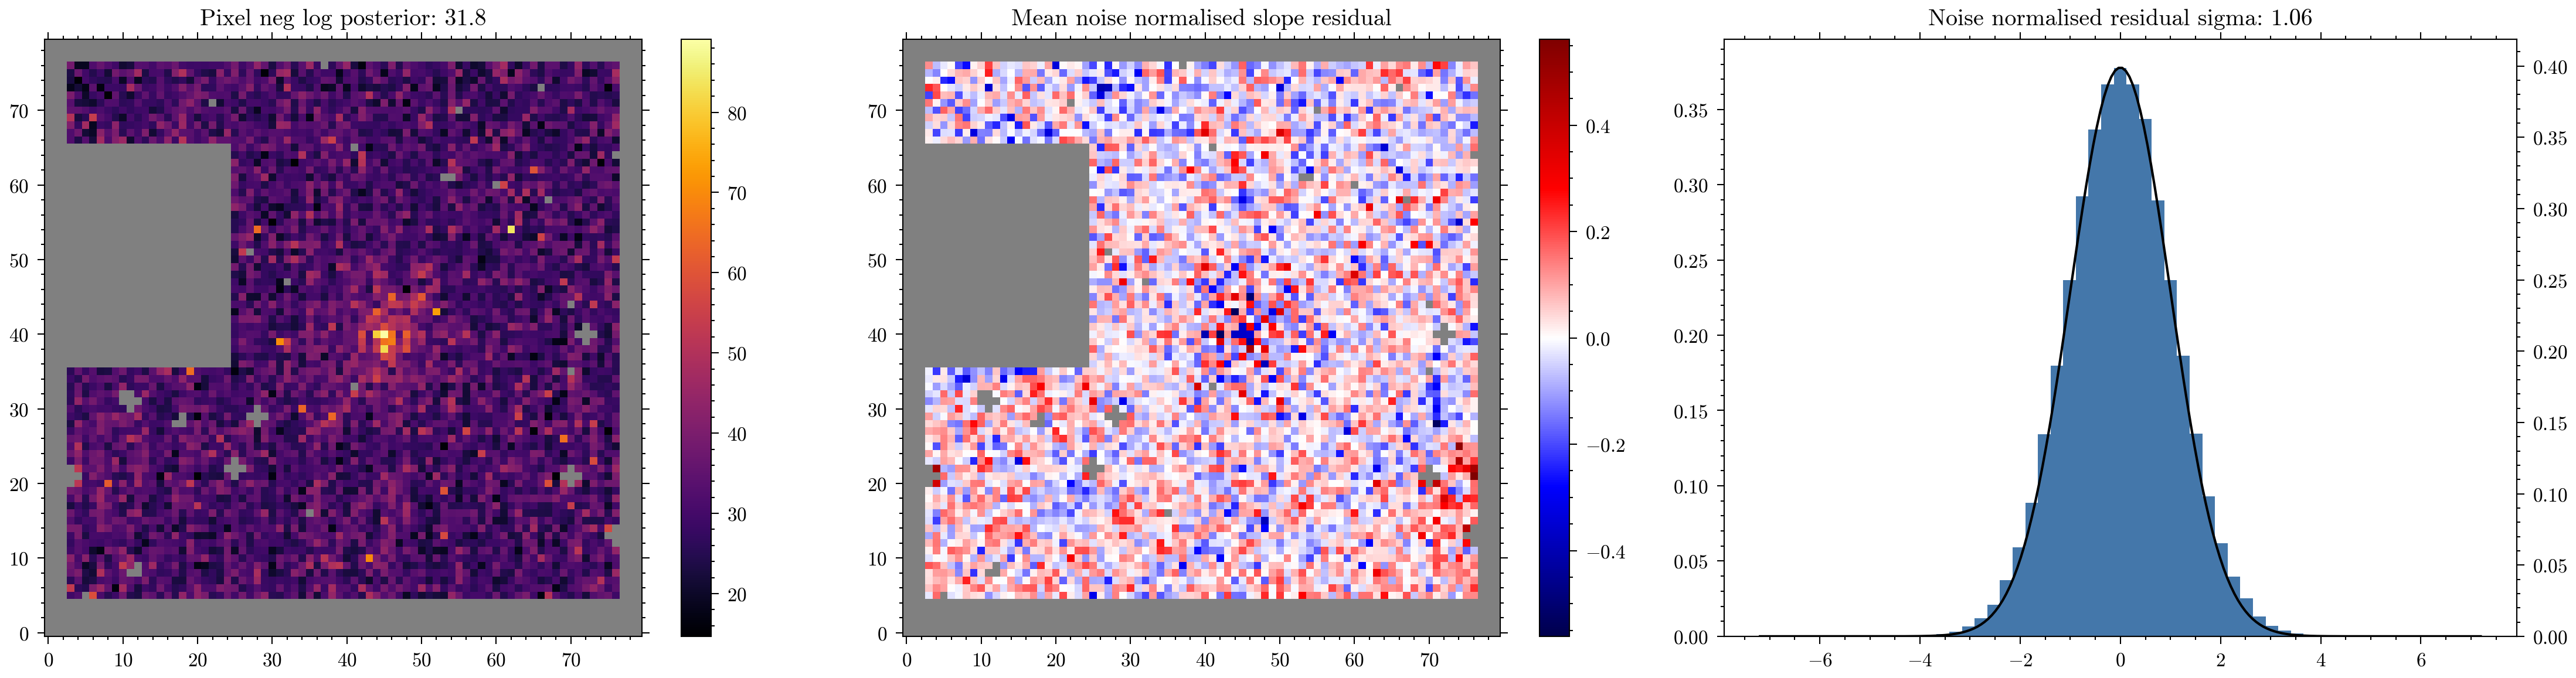

F430M Calibrator HD 228337 20


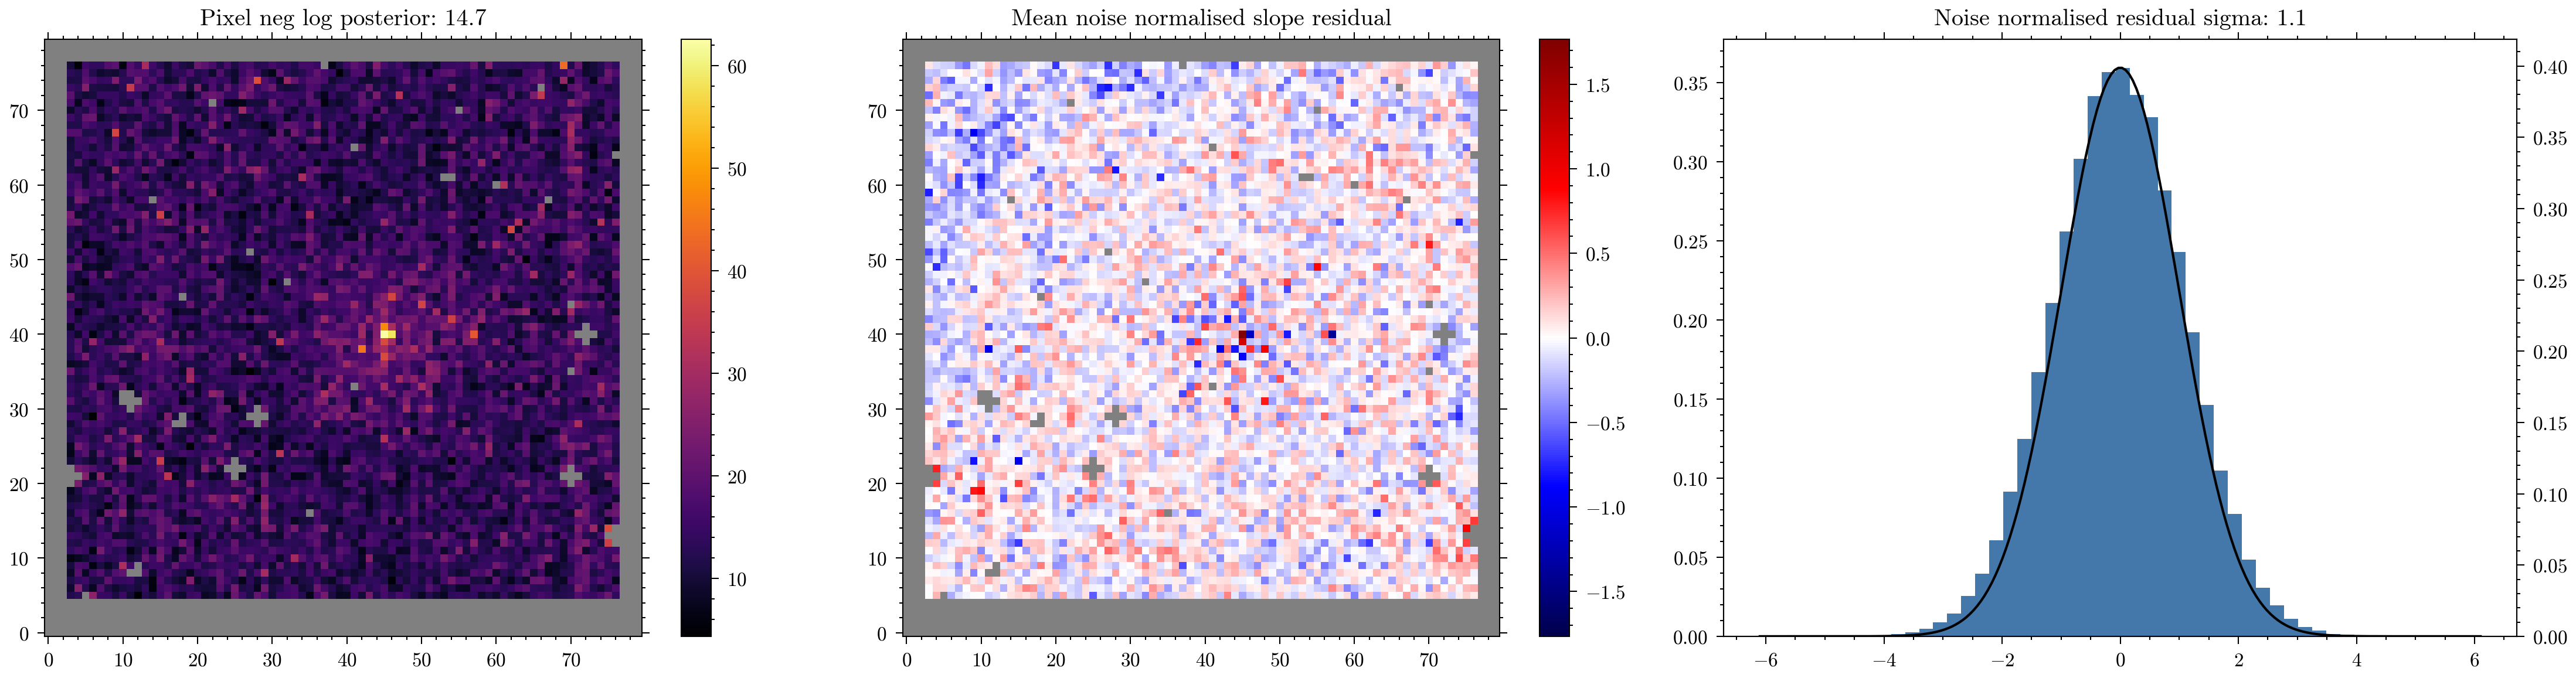

F430M Science TD-PDS-70 64


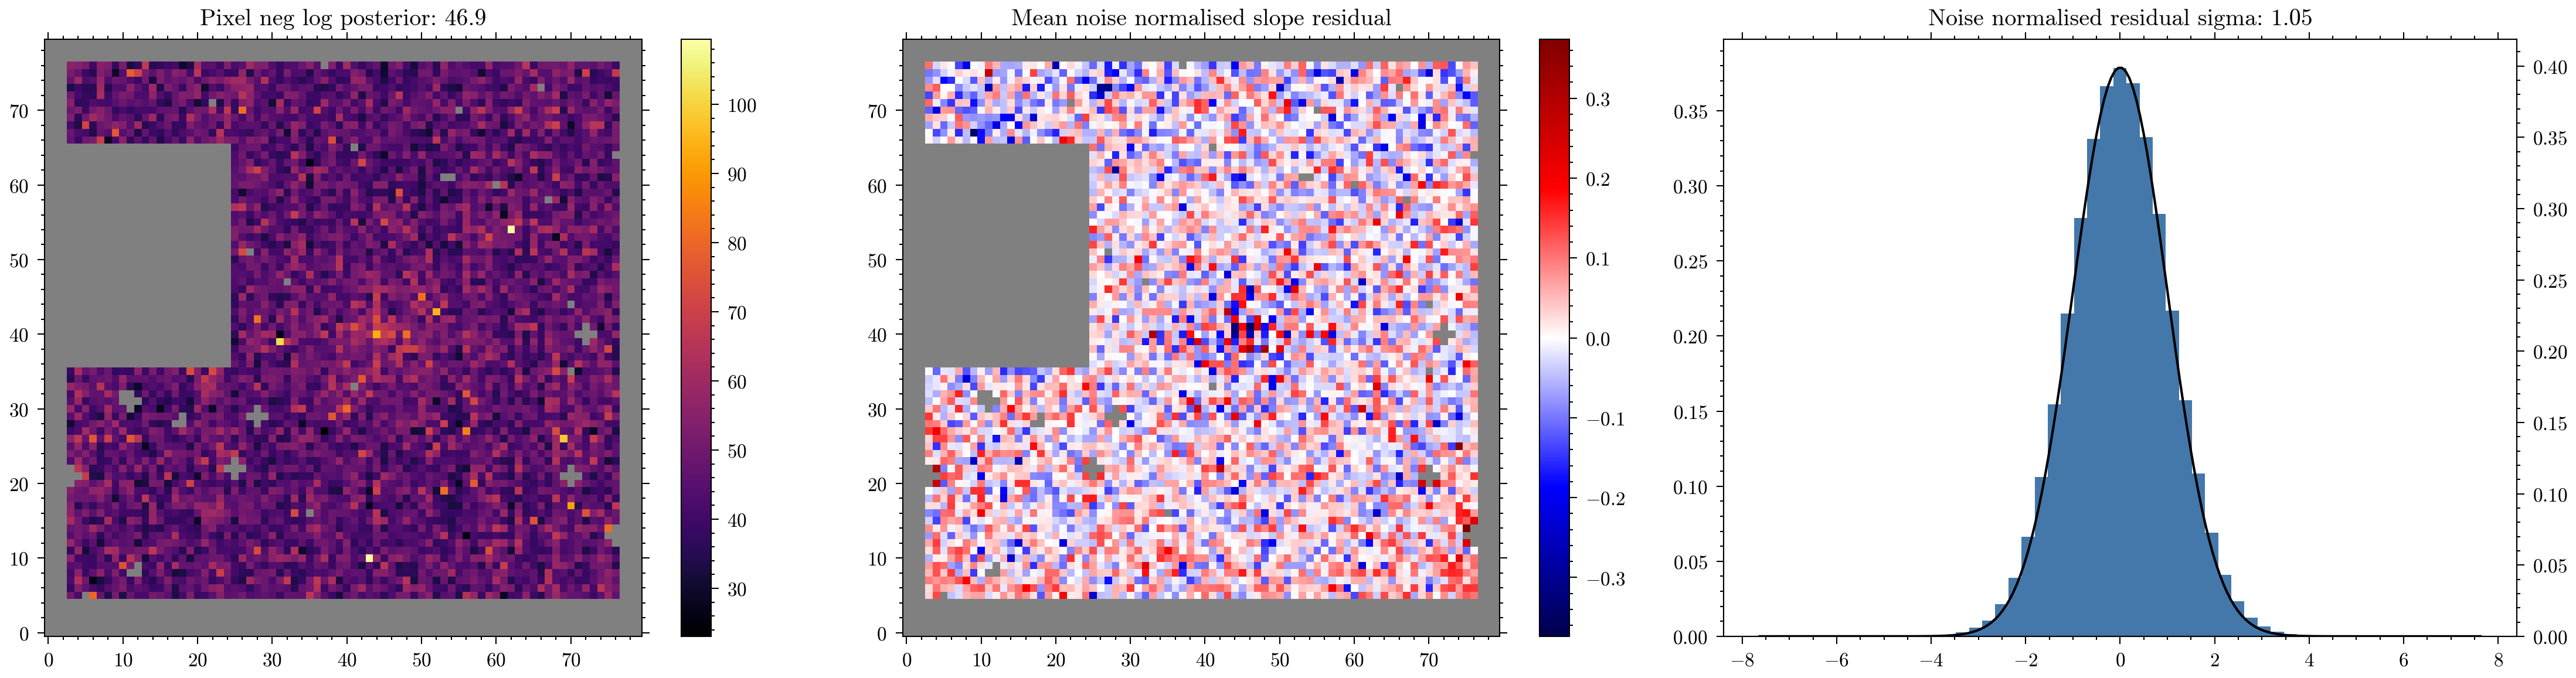

F480M Calibrator HD 228337 29


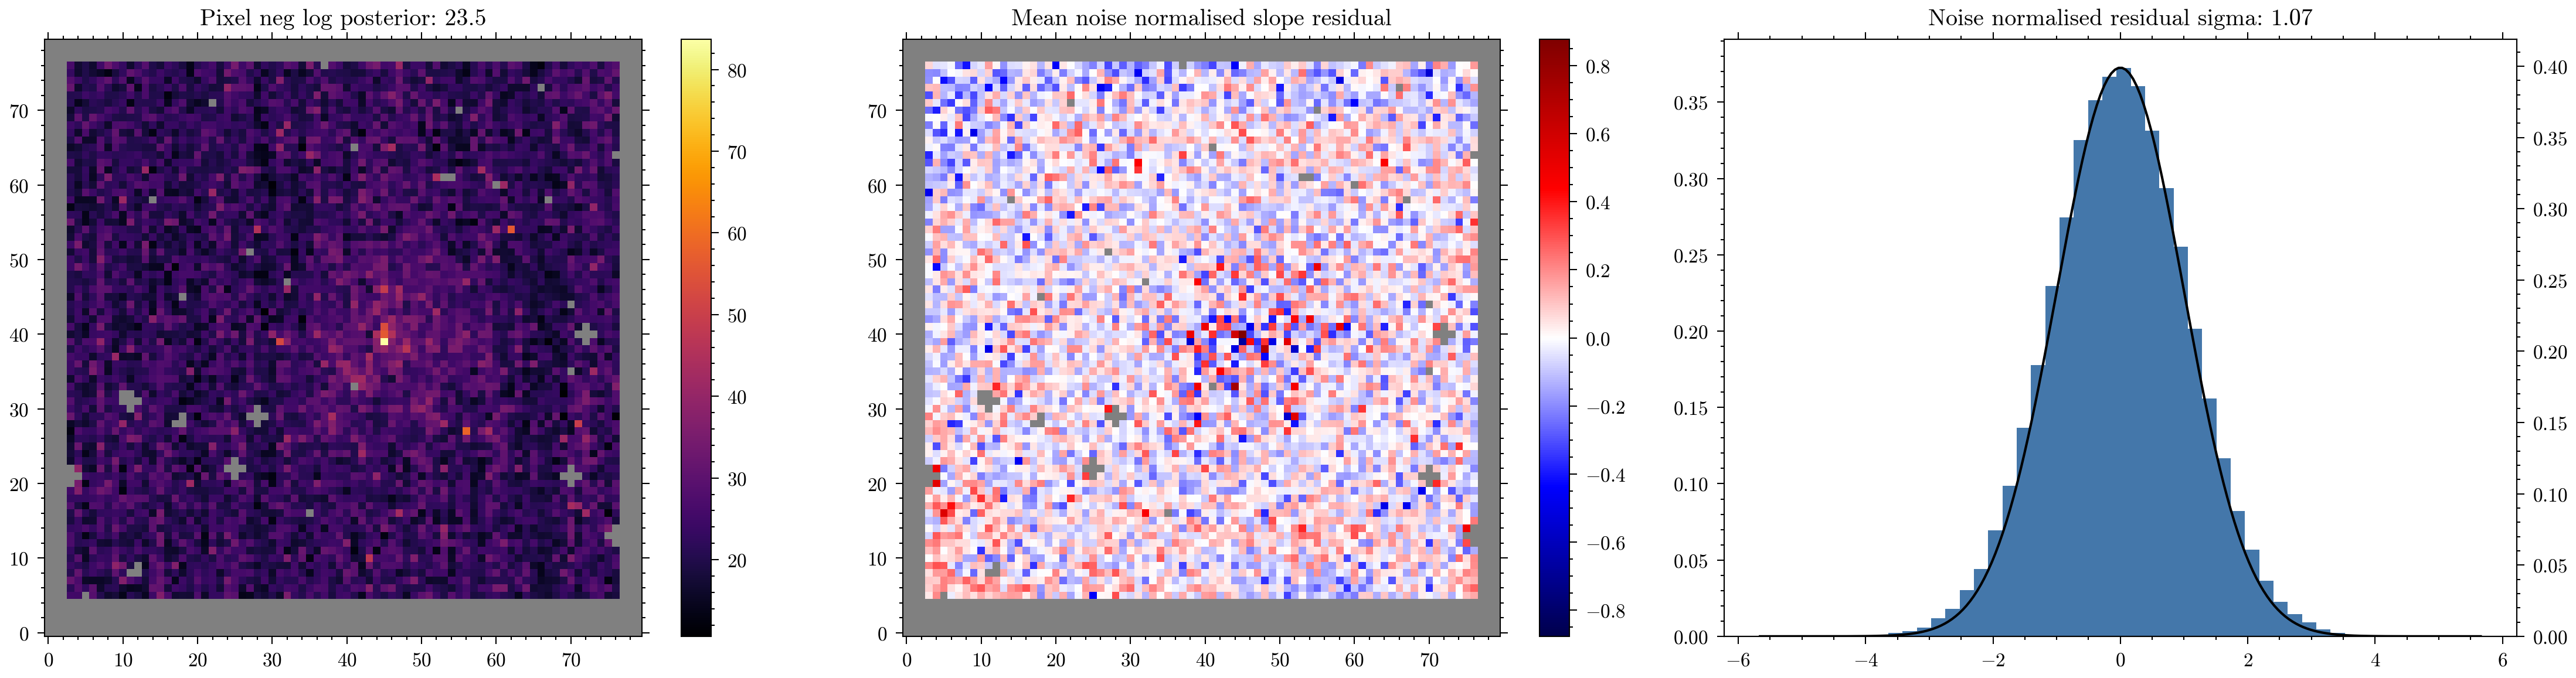

F480M Science TD-PDS-70 96


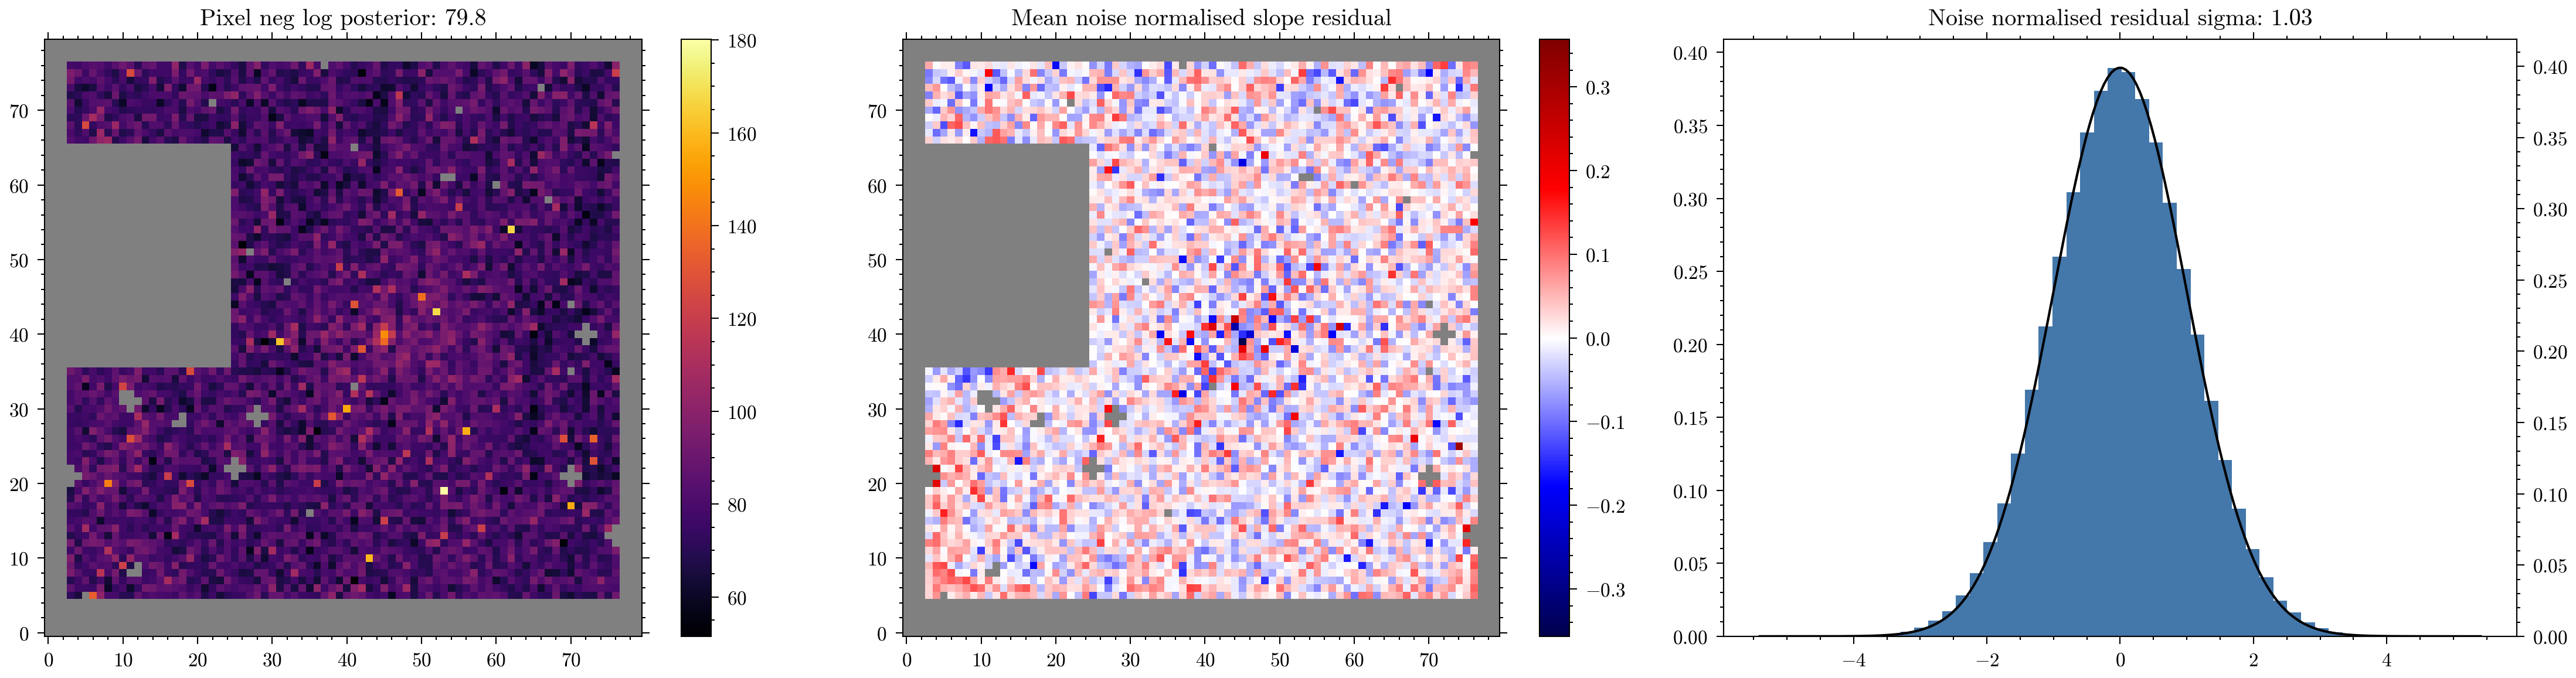

In [ ]:
for filt in ["F380M", "F430M", "F480M"]:
    for exp in exposures:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            amigo.plotting.summarise_fit(final_model, exp)

In [ ]:
# np.save("files/bgmaskparams_pds70.npy", final_model.params, allow_pickle=True)

final_model = model.set(
    "params", np.load("files/bgmaskparams_pds70.npy", allow_pickle=True).item()
)

In [ ]:
import jax.tree as jtu
from tqdm.notebook import tqdm
from amigo.fisher import FIM


fmats = {}
for exp in tqdm(exposures):
    loglike_fn = lambda model: -np.nansum(exp.loglike(model))
    params = [exp.map_param("amplitudes"), exp.map_param("phases")]
    fmat = FIM(final_model, params, loglike_fn, reduce_ram=True, batch_size=10)
    fmats[exp.get_key("phases")] = fmat

  0%|          | 0/6 [00:00<?, ?it/s]

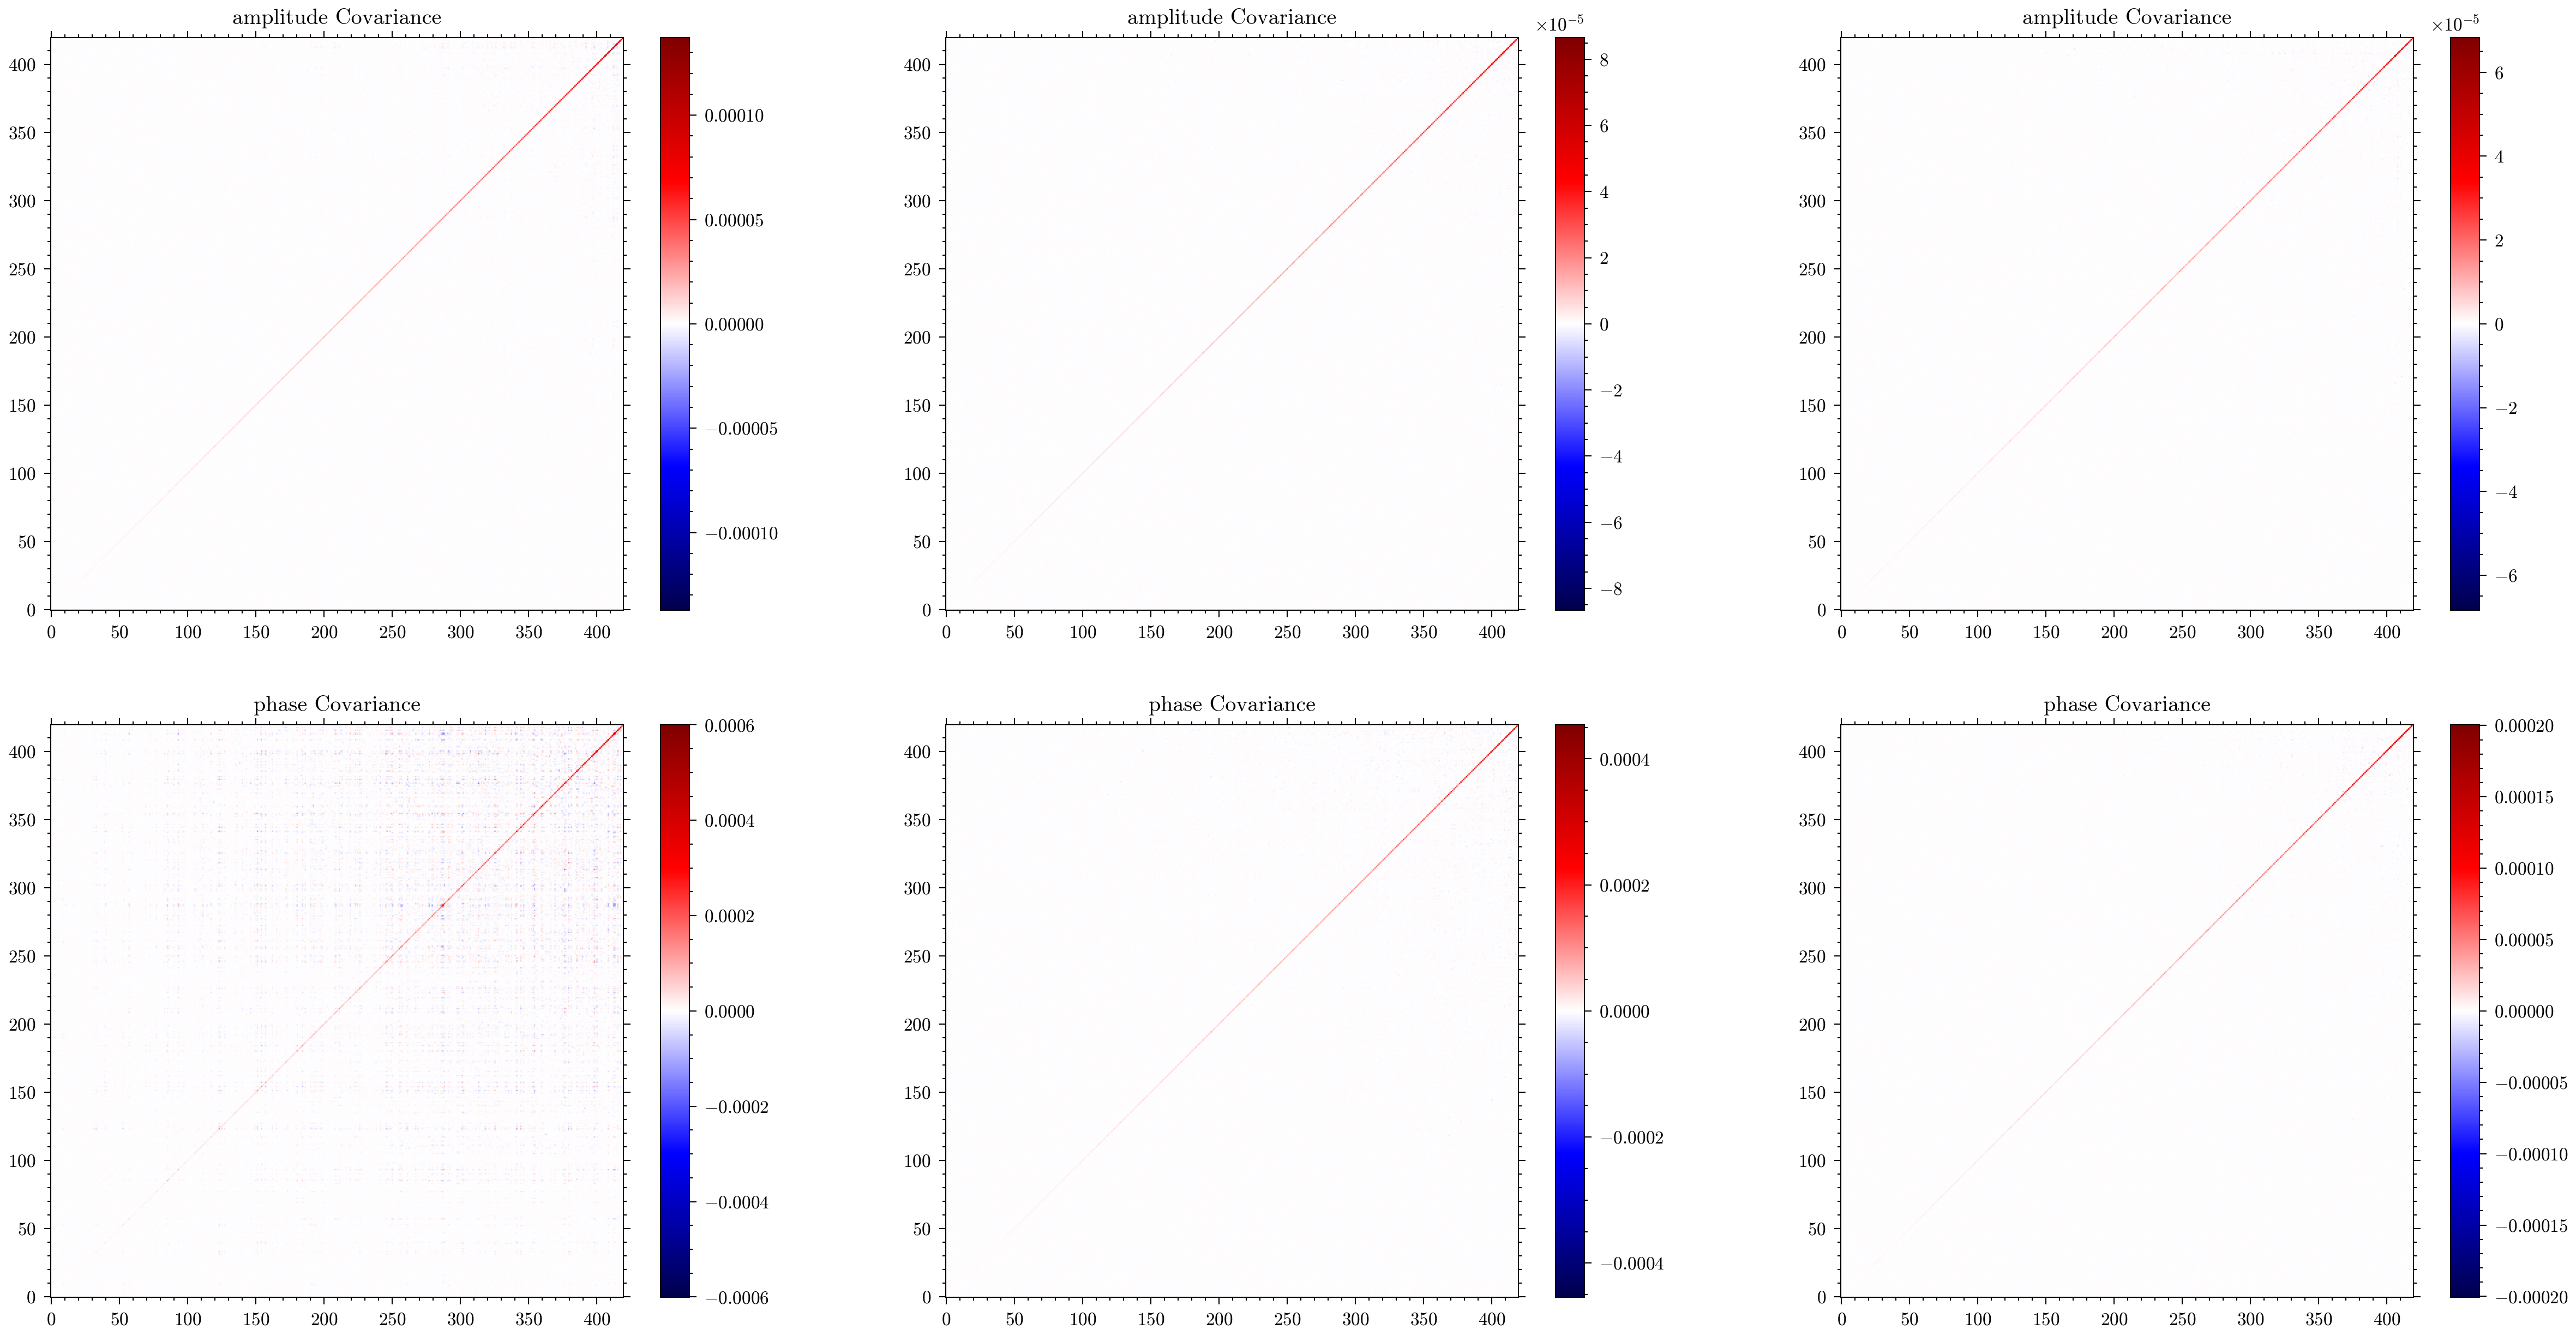

In [ ]:
full_covs = jtu.map(lambda x: np.linalg.inv(x), fmats)

n = model.vis_model.n_basis
amp_covs = jtu.map(lambda x: x[:n, :n], full_covs)
phase_covs = jtu.map(lambda x: x[n:, n:], full_covs)

covs = {
    "amplitudes": amp_covs,
    "phases": phase_covs,
}

plt.figure(figsize=(20, 10))
for i, key in enumerate(amp_covs):
    if i > 5:
        break

    if i < 3:
        param = "amplitude"
        cov = amp_covs[key]
    else:
        param = "phase"
        cov = amp_covs[key]
    plt.subplot(2, 3, i + 1)
    plt.title(f"{param} Covariance")
    v = np.nanmax(np.abs(cov))
    plt.imshow(cov, seismic, vmin=-v, vmax=v)
    # plt.imshow(np.log10(np.abs(cov)), inferno)
    plt.colorbar()
plt.show()

In [ ]:
fit_outputs = {
    "n_basis": final_model.vis_model.n_basis,
}

for exp in exposures:
    get_fn = lambda param: final_model.get(exp.map_param(param))
    fit_outputs[exp.key] = {
        "star": exp.star,
        "calibrator": exp.calibrator,
        "filter": exp.filter,
        "parang": exp.parang,
        "defocus": final_model.get(exp.map_param("defocus")),
        "n_basis": final_model.vis_model.n_basis,
        "fishers": fmats[exp.get_key("phases")],
        "amp_cov": amp_covs[exp.get_key("phases")],
        "phase_cov": phase_covs[exp.get_key("phases")],
        **{param: get_fn(param) for param in final_state.keys()},
    }

np.save(output_path + f"bgmask_visibilities", fit_outputs, allow_pickle=True)